# Análisis Exploratorio de Datos (EDA) a BankMarketing 

Responsable: Pamela Cerdas 

Objetivo general: 

Analizar los patrones en la toma de decisiones de los clientes de BankMarketing, y su relacion con las variables externas.



In [ ]:
# Importar librerias 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
## Codigo para representacion grafica visual 
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
from pathlib import Path

## Parte 1 
Exploración inicial 

## Ingesta del archivo bronce "Raw" desde la carperta intesgion\ ingest.py

In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA = PROJECT_ROOT / "data" / "raw" / "bank_marketing.csv"

print(RAW_DATA)


c:\Users\Usuario\Documents\Proyecto Integrador\BankMarketing-MLOps\data\raw\bank_marketing.csv


In [3]:
df = pd.read_csv(RAW_DATA)

### Visualización del dataset 

In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [ ]:
df.columns #definir las columnas del dataset


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

In [ ]:
df.shape # visualizar la cantidad de filas y columnas totales del dataset

(45211, 17)

Con respecto a la exploración inicial, como se puede observar el dataset contiene un total de 45,211 observaciones y 17 variables (columnas), por lo que se define que existe suficiente informacion de datos, sin recurrir a aumentar de manera abrupta los datos.

## Parte 2 Calidad de los datos 

In [ ]:
df.info() # observar el tipo de datos de cada columna y la cantidad de valores no nulos en el dataset 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Se indentifico un total de 7 variables numéricas y 11 categóricas, por lo que segun el analisis en cuestion la variable y, la cual indica las 2 opciones de respuesta (yes) o (no), se recomienda aplicar la tecnica de codificación One-Hot Encoding que prevenga data leakage para que codifique los valores categoricos como numéricos, de manera de vectorial individuamente y matricial a nivel del dataset, para una mejor visualización y control de dimensiones. 

In [38]:
df.isnull().sum() # visualizacion e identificación de la cantidad de valores nulos por variable en el dataset

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64

In [39]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

poutcome       81.747805
contact        28.798301
education       4.107407
job             0.637013
age             0.000000
default         0.000000
balance         0.000000
housing         0.000000
marital         0.000000
loan            0.000000
day_of_week     0.000000
duration        0.000000
month           0.000000
campaign        0.000000
pdays           0.000000
previous        0.000000
y               0.000000
dtype: float64

Analisis de los valores nulos, con respecto a las variables poutcome, contact, education y job, se identifica que la variable poutcome contiene un 81.78% de valores nulos o faltantes, sin embargo, antes de una decisión de imputación en esta y las demás variables, se procede a realizar un analisis más exahustivo, tomando el supuesto de que puede corresponder a una variable mal nombrada o no identificada. 

In [40]:
df.duplicated().sum() # comprobación de la existencia de valores duplicados en el dataset

np.int64(0)

No se encontraron duplicados 

#### Investigación de las variables sospechosas por valores faltantes altos 

In [41]:
df["poutcome"].value_counts(dropna=False) # Visualizacion de los datos faltantes, sin embargo, se utiliza dropna=False para que muestre los valores de NaN 

poutcome
NaN        36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [42]:
df["contact"].value_counts(dropna=False) 

contact
cellular     29285
NaN          13020
telephone     2906
Name: count, dtype: int64

In [43]:
df[["previous", "pdays", "poutcome"]].head(20) 

,previous,pdays,poutcome
0,0,-1,NaN
1,0,-1,NaN
2,0,-1,NaN
3,0,-1,NaN
4,0,-1,NaN
5,0,-1,NaN
6,0,-1,NaN
7,0,-1,NaN
8,0,-1,NaN
9,0,-1,NaN


In [44]:
pd.crosstab(
    df["previous"] == 0,
    df["poutcome"].isnull()
) 

poutcome,False,True
previous,,
False,8252,5
True,0,36954


Según lo visto anteriormente, la resultados indican que en la variable de poutcome el valor de NaN no es solamente una linea vacia o un error de captura, ya que, como se puede observar en la tabla cruzada, los valores de NaN estan relacionados a Previos = 0, por lo que indica que no hubo un contacto previo a la campaña de suscripción actual, por lo que se decide mantener la variable poutcome, ahora bien, la variable pdays la cual indica el numero de dias posteriores al contacto, este -1 aparece también relacionado con previous y poutcome, en el que un resultado de 0 en previous, indica -1 en pdays, por consecuencia en poutcome NaN, lo que indica -1 es que no hay un contacto previo con el cliente.

Apartir de la información anterior, se busca responder por qué hay tantas respuestas en NaN?

In [45]:
df["previous"].describe()

count    45211.000000
mean         0.580323
std          2.303441
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64

Como se puede observar en las medidas descriptivas en la variable previous, los registros corresponden a 45211, la media indica 0.58, es decir los clientes no llegron a un contacto previo, siendo la mediana 0, por esta razon tantos NaN, entonces como se puede observar el minimo es 0 y el maximo es de 275, en donde los percentiles 25,50 y 75 son de 0, por lo que, con información estadistica las variables a estudio por altos valores nulos, corresponden a que los clientes no recibieron un contacto previo por lo que hay un desbalanceo en el dataset con respecto a la variable objetivo Y que indica un alto porcentaje en respuestas de (no). 

In [46]:
df.nlargest(10, "previous")

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
29182,40,management,married,tertiary,no,543,yes,no,cellular,2,feb,349,2,262,275,other,no
38326,46,blue-collar,married,primary,no,1085,yes,yes,cellular,15,may,523,2,353,58,other,yes
44089,37,technician,married,secondary,no,432,yes,no,cellular,6,jul,386,3,776,55,failure,yes
28886,31,management,single,tertiary,no,358,yes,no,cellular,30,jan,68,3,256,51,failure,no
44822,27,blue-collar,married,secondary,no,821,yes,yes,NaN,16,sep,23,1,778,41,other,no
42611,35,technician,single,secondary,no,4645,yes,no,cellular,11,jan,502,3,270,40,other,no
28498,49,management,single,tertiary,no,145,yes,no,cellular,29,jan,57,2,248,38,failure,no
37567,39,management,married,tertiary,no,0,yes,no,cellular,14,may,11,15,261,38,failure,no
26668,51,entrepreneur,married,secondary,no,653,yes,no,cellular,20,nov,16,9,112,37,other,no
42422,27,student,single,secondary,no,91,no,no,telephone,4,dec,157,6,95,37,other,no


Como se puede observar previous se encuentra bastante sesgada, ademas como se puede observar un cliente recibio 275 llamadas, para una respuesta de la variable objetivo de (no), se recomienda StandardScaler o transformacion logaritmica para que estos no influyan negativamente en ML.

In [47]:
df["day_of_week"].value_counts().sort_index()

day_of_week
1      322
2     1293
3     1079
4     1445
5     1910
6     1932
7     1817
8     1842
9     1561
10     524
11    1479
12    1603
13    1585
14    1848
15    1703
16    1415
17    1939
18    2308
19    1757
20    2752
21    2026
22     905
23     939
24     447
25     840
26    1035
27    1121
28    1830
29    1745
30    1566
31     643
Name: count, dtype: int64

La variable day_of_week, muestra valores entre 1 y 31, por lo que indica un día del mes, y no un día de la semana, por lo que se recomienda el renombre de esta variable a "day_of_month 

## Parte 3 Análisis de la variable Y (objetivo)
Variable objetivo del análisis 

In [8]:
df["y"].value_counts(normalize=True) * 100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

La variable Y, la cual responde al exito de contratacion o suscripcion de un depósito bancario, se encuentra desbalanceada, comol se puede observar:
1- 88.30% de los clientes, no se suscribieron al depósito
2- 11.69% de los clientes, si se suscribieron al depósito 

Lo cual indica a un importante desblanceo entre estas clases de la variable Y, lo cual sugiere que la metrica Accuracy puede ser no cierta, por lo que se recomienda utilizar las metricas de evaluacion: Precision, Recall, F1- score y Roc. Esto para una eleccion de modelo mas robusto y reproducible. 

## Parte 4 Análisis descriptivo inicial 

In [48]:
df.describe()


,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Resultados inciales
Con el fin de identificar los valores que pueden influir en el modelado, se realizo el analisis de las variables numericas. 
Age muestra una media y mediana relativamente similiar, con una minima de 18 y un maximo de 95, lo que indica la edad en la que rondan los clientes.
Balance esta variable muestra dispersion con respecto a la mediana y mediana indicando la presencia de valores atipicos que se representan en unidades monetarias, en un ambiente bancario estas dispersiones estan dentro de lo esperado puesto que existen clientes con diferentes montos. 
day_of_week muestra una media y mediana relativamente cercanas, ahora bien, en el minimo 1 y el maximo 31, este indica que son valores del mes como antes ya analizado. 
duration muestra gran dispersion de los datos, la media indica 258 segundos y la mediana 180, con un minimo de 0 y un maximo de 4918 lo que indica que clientes no reciben llamadas mientras otros tienen llamadas extremandamente largas. 
campaing muestra una media y mediana similares, sin embargo, el minimo indica 1 de los contactos de la campaña actual mientras que la maxima 63 contactos, por lo que se debe de analizar con outliers.
pdays muestra una alta concentración del valor -1.
previous muestra una fuerte dispersion como se analizo anteriormente y en el analisis descriptivo, la media muestra 0.58 llamadas previas mientras que la mediana 0, pero el minimo siendo de 0 y el maximo de 275.



## Parte 5 Análisis de la relación de las variables explicativas y la objetivo

In [33]:
pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
)

y,no,yes
job,,
admin.,0.877973,0.122027
blue-collar,0.927250,0.072750
entrepreneur,0.917283,0.082717
housemaid,0.912097,0.087903
management,0.862444,0.137556
retired,0.772085,0.227915
self-employed,0.881571,0.118429
services,0.911170,0.088830
student,0.713220,0.286780


Se realiza en analisis de relacion de job con Y, ya que, la ocupación de los clientes influye en la decision de suscripción, como se puede observar student tienen un 28% de (si) y services 8%, siendo una candidata en el modelo predictivo, se recomienda enconding al ser categorica. 

<Axes: xlabel='y', ylabel='age'>

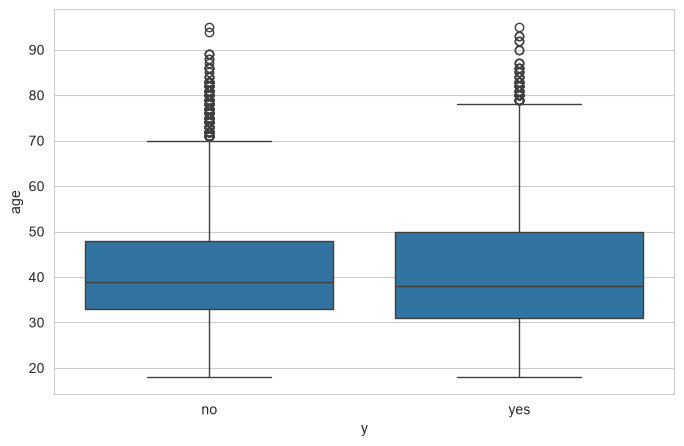

In [34]:
sns.boxplot(
    data=df,
    x="y",
    y="age"
)

con respecto a la variable age, con la variable objetivo Y, se procede a conservar la variable para ML, puesto que existe diferencia no es de las mas fuertes sin embargo, si muestra diferencia entre las medias como se puede observar, la edad entre mas arriba o mayor sea, es mayor la tasa de aceptabilidad. 

## Parte 6 Correlación entre las variables 

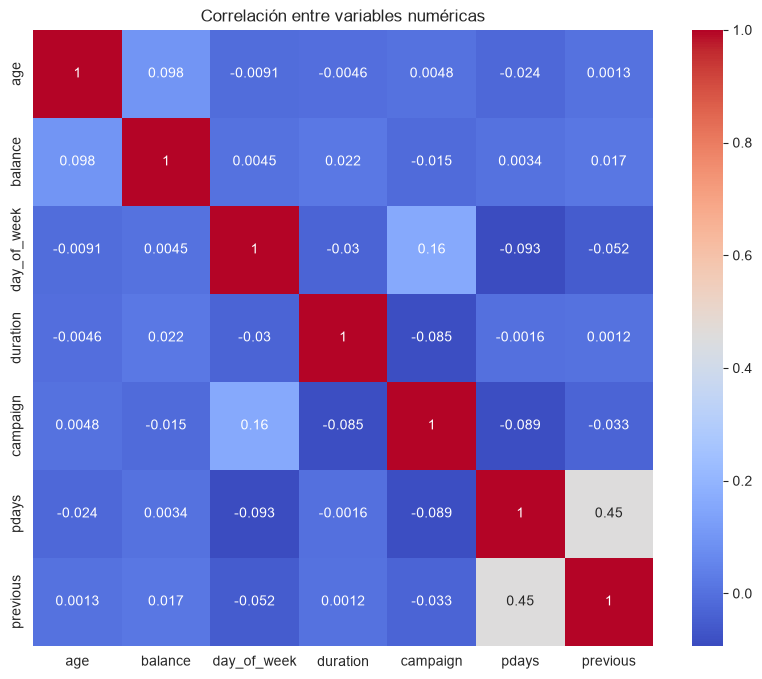

In [36]:
numericas = df.select_dtypes(include=np.number)

corr = numericas.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlación entre variables numéricas")
plt.show()

Con respecto a la multicolinealidad entre las variables numericas, para identificar las relaciones entre las mismas, se observa que entre las variables la mayoria se encuentran en numeros muy bajos, estos cercanos a cero, lo que indica que no hay o es muy poca la relacion, sin embargo se identifica que pdays y previous tiene una correlación de 0.45 la cual es la más alta del dataset, lo cual como se menciono anteriormente estas responden a la informacion asociada al historial de llamadas, seguidamente de age y balance con 0.10 

## Parte 7 Identificación y evaluación de outliers 

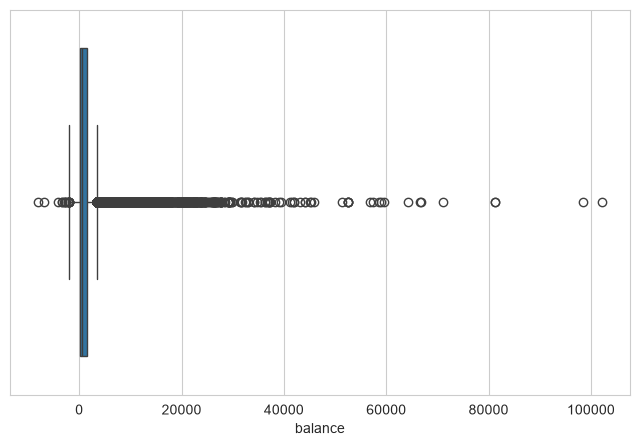

In [22]:
### Identificacion de outliers en las variables numericas
sns.boxplot(x=df["balance"])
plt.show()

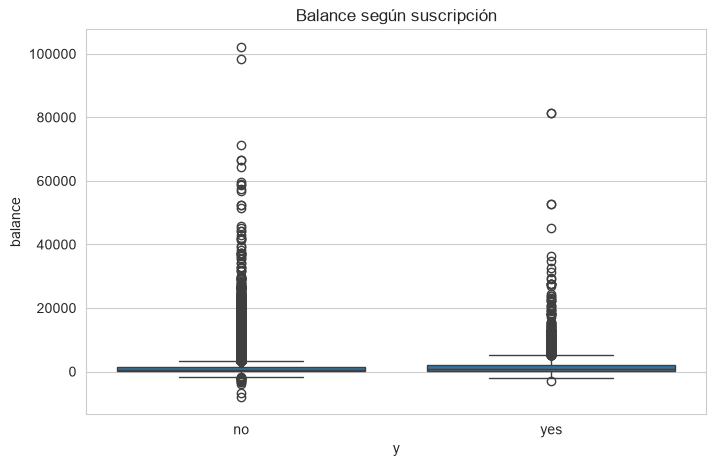

In [23]:
sns.boxplot(
    data=df,
    x="y",
    y="balance"
)

plt.title("Balance según suscripción")
plt.show()

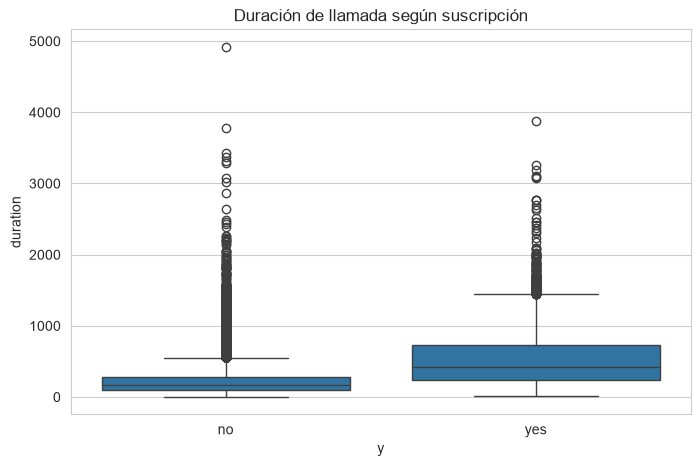

In [24]:
sns.boxplot(
    data=df,
    x="y",
    y="duration"
)

plt.title("Duración de llamada según suscripción")
plt.show()

In [25]:
df.loc[df["duration"].idxmax(), "y"]

'no'

In [26]:
(df["duration"] > 3600).sum()

np.int64(3)

In [27]:
((df["duration"] > 3600).sum() / len(df)) * 100

np.float64(0.0066355532945522105)

In [28]:
df[df["duration"] > 3600]["y"].value_counts()

y
no     2
yes    1
Name: count, dtype: int64

In [29]:
pd.crosstab(df["job"], df["y"], normalize="index")

y,no,yes
job,,
admin.,0.877973,0.122027
blue-collar,0.927250,0.072750
entrepreneur,0.917283,0.082717
housemaid,0.912097,0.087903
management,0.862444,0.137556
retired,0.772085,0.227915
self-employed,0.881571,0.118429
services,0.911170,0.088830
student,0.713220,0.286780


In [30]:
pd.crosstab(df["education"], df["y"], normalize="index")

y,no,yes
education,,
primary,0.913735,0.086265
secondary,0.894406,0.105594
tertiary,0.849936,0.150064


In [31]:
pd.crosstab(df["poutcome"], df["y"], normalize="index")

y,no,yes
poutcome,,
failure,0.873903,0.126097
other,0.833152,0.166848
success,0.352747,0.647253


## Parte 8 Transformaciones propuestas para Feature Engineering 

# Conclusiones

1. El target presenta desbalance de clases.
2. Job, education y poutcome muestran asociación con la conversión.
3. Los NaN de poutcome representan ausencia de campañas previas.
4. El valor -1 de pdays representa una condición especial de negocio.
5. Duration presenta una fuerte relación con la variable objetivo y requiere evaluación por posible leakage.
6. No se identifican problemas importantes de multicolinealidad.
7. Se proponen transformaciones para la etapa de preprocessing.